## PlantVillage + Vision Transformer: 식물 잎 병해 분류 PoC

**PlantVillage**(작물 잎 병해 벤치마크)와 HuggingFace **ViT** 사전학습 모델로
잎 이미지의 **시각 표현(임베딩)** 을 만들고, **Cosine Similarity** 기반으로
정상/병해를 구분하는 **Proof of Concept** 예제입니다.

전체 38클래스·5만 장은 용량이 커서, **감자(Potato) 3클래스만** 소량 샘플링합니다.

| 섹션 | 내용 |
|------|------|
| PlantVillage | GitHub에서 Potato 3클래스만 다운로드 (클래스당 소수 장) |
| Image Embedding | ViT hidden state → CLS / Mean Pooling → L2 정규화 |
| Similarity 분석 | 정상 프로토타입 대비 Cosine Similarity, 유사도 행렬 시각화 |
| 병해 분류 PoC | (1) 정상 프로토타입 이상 점수 (2) k-NN 메모리 (3) 3클래스 k-NN |

**선택한 클래스 (Potato)**
- `Potato___healthy` — 정상
- `Potato___Early_blight` — 겹무늬병
- `Potato___Late_blight` — 역병

> **실행 환경**: Google Colab (GPU 권장) 또는 로컬 Jupyter  
> **데이터**: [PlantVillage](https://github.com/spMohanty/PlantVillage-Dataset) Potato 서브셋 (약 200장, 수 MB)  
> **모델**: `google/vit-base-patch16-224` (ImageNet 사전학습)

<br>
PoC(Proof of Concept): 이 기술이나 아이디어가 실제로 가능한지 먼저 검증해 보는 작은 규모의 실험


### 1. 환경 설정 및 패키지 설치


In [1]:
# ========== 실행 환경 감지 ==========
try:
    import google.colab
    IN_COLAB = True
    print('Google Colab 환경에서 실행 중')
except ImportError:
    IN_COLAB = False
    print('로컬 Jupyter 환경에서 실행 중')


Google Colab 환경에서 실행 중


In [2]:
# ========== 패키지 설치 (최초 1회) ==========
# if IN_COLAB:
#     %pip install -q transformers datasets scikit-learn seaborn

# 로컬 터미널 예시:
# py -3.11 -m pip install transformers datasets scikit-learn pillow matplotlib seaborn


In [3]:
# ========== 라이브러리 import ==========
import io
import logging
import time
import urllib.error
import urllib.request
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from typing import Literal
from urllib.parse import quote

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn.functional as F

from datasets import ClassLabel, Dataset, Features, Value
from datasets import Image as HFImage
from huggingface_hub import hf_hub_download
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from transformers import AutoImageProcessor, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

KOREAN_FONT_CANDIDATES = [
    'Malgun Gothic', 'AppleGothic', 'NanumGothic',
    'NanumBarunGothic', 'Noto Sans CJK KR', 'Noto Sans KR',
]
NANUM_TTF_URL = (
    'https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf'
)


def _find_installed_korean_font() -> str | None:
    available = {font.name for font in fm.fontManager.ttflist}
    for name in KOREAN_FONT_CANDIDATES:
        if name in available:
            return name
    return None


def _install_nanum_font() -> None:
    """Colab 등 한글 폰트가 없는 환경에서 나눔고딕을 설치/등록한다."""
    # 1) apt 로 시스템 설치 시도 (Colab은 root 권한)
    try:
        import subprocess
        subprocess.run(
            ['apt-get', '-qq', '-y', 'install', 'fonts-nanum'],
            check=True, capture_output=True,
        )
    except Exception:
        pass

    # 2) apt 가 없거나 실패한 경우 ttf 직접 다운로드
    downloaded = Path.home() / '.cache' / 'nanum' / 'NanumGothic-Regular.ttf'
    if not any('nanum' in Path(p).name.lower() for p in fm.findSystemFonts()):
        try:
            downloaded.parent.mkdir(parents=True, exist_ok=True)
            req = urllib.request.Request(
                NANUM_TTF_URL, headers={'User-Agent': 'Mozilla/5.0'}
            )
            with urllib.request.urlopen(req, timeout=30) as resp:
                downloaded.write_bytes(resp.read())
        except Exception:
            downloaded = None

    # 3) matplotlib 폰트 매니저에 새 폰트 등록
    font_files = list(fm.findSystemFonts())
    if downloaded is not None and Path(downloaded).exists():
        font_files.append(str(downloaded))
    for fpath in font_files:
        if 'nanum' in Path(fpath).name.lower():
            try:
                fm.fontManager.addfont(fpath)
            except Exception:
                pass


def setup_korean_font() -> str:
    name = _find_installed_korean_font()
    if name is None:
        _install_nanum_font()
        name = _find_installed_korean_font()

    plt.rcParams['axes.unicode_minus'] = False
    if name is not None:
        plt.rcParams['font.family'] = name
        return name
    return 'DejaVu Sans'


logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
print(f'matplotlib 한글 폰트: {setup_korean_font()}')

RNG = np.random.default_rng(42)
torch.manual_seed(42)


사용 디바이스: cuda
matplotlib 한글 폰트: NanumGothic


### 2. PlantVillage 데이터셋 로드 (Potato 3클래스)

[PlantVillage](https://github.com/spMohanty/PlantVillage-Dataset)는 14작물·38클래스·약 5.4만 장입니다.
여기서는 HuggingFace 공식 80/20 분할 목록을 읽고, **감자 3클래스만** GitHub에서 내려받습니다.

- `train`: 학습용 **정상(healthy)** 이미지만 (이상 탐지 PoC 기준)
- `test`: 정상 + 겹무늬병 + 역병 혼합
- 이진 라벨: `0=healthy`, `1=diseased`


In [4]:
# ========== PlantVillage (Potato 서브셋) 로드 ==========
PV_HF_ID = 'mohanty/PlantVillage'
GITHUB_RAW = 'https://raw.githubusercontent.com/spMohanty/PlantVillage-Dataset/master'
CACHE_DIR = Path('./data/plantvillage_potato')

SELECTED_CLASSES = [
    'Potato___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
]
CLASS_DISPLAY = {
    'Potato___healthy': '정상',
    'Potato___Early_blight': '겹무늬병',
    'Potato___Late_blight': '역병',
}
LABEL_NAMES = {0: 'healthy', 1: 'diseased'}

# 전체 데이터 대신 클래스당 소수만 사용
MAX_TRAIN_HEALTHY = 80
MAX_TRAIN_PER_DISEASE = 40   # 지도 3클래스 k-NN용
MAX_TEST_PER_CLASS = 24

USER_AGENT = {'User-Agent': 'PlantVillage-ViT-PoC/1.0'}


def _read_split_file(filename: str) -> list[str]:
    path = hf_hub_download(
        repo_id=PV_HF_ID,
        repo_type='dataset',
        filename=filename,
    )
    return Path(path).read_text(encoding='utf-8').splitlines()


def _class_from_relpath(relpath: str) -> str | None:
    parts = relpath.strip().split('/')
    if len(parts) < 4:
        return None
    return parts[2]


def sample_split_paths(
    lines: list[str],
    class_names: list[str],
    max_per_class: dict[str, int],
    rng: np.random.Generator,
) -> list[str]:
    buckets: dict[str, list[str]] = {c: [] for c in class_names}
    for line in lines:
        rel = line.strip()
        cls = _class_from_relpath(rel)
        if cls in buckets:
            buckets[cls].append(rel)

    picked: list[str] = []
    for cls in class_names:
        paths = buckets[cls]
        cap = max_per_class.get(cls, 0)
        if cap <= 0 or not paths:
            continue
        order = rng.permutation(len(paths))
        picked.extend(paths[i] for i in order[: min(cap, len(paths))])
    return picked


def _download_one(relpath: str, retries: int = 3) -> Path:
    dest = CACHE_DIR / relpath
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size > 1000:
        return dest

    url = f'{GITHUB_RAW}/{quote(relpath, safe="/")}'
    last_exc: Exception | None = None
    for attempt in range(1, retries + 1):
        req = urllib.request.Request(url, headers=USER_AGENT)
        tmp = dest.with_suffix(dest.suffix + '.part')
        try:
            with urllib.request.urlopen(req, timeout=30) as resp:
                tmp.write_bytes(resp.read())
            tmp.replace(dest)
            return dest
        except (urllib.error.URLError, TimeoutError, OSError) as exc:
            last_exc = exc
            if tmp.exists():
                tmp.unlink(missing_ok=True)
            time.sleep(0.4 * attempt)
    raise RuntimeError(f'다운로드 실패: {relpath} ({last_exc})') from last_exc


def download_images(relpaths: list[str], max_workers: int = 8) -> list[Path]:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    paths: list[Path] = [Path()] * len(relpaths)
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(_download_one, rel): i for i, rel in enumerate(relpaths)}
        for fut in as_completed(futures):
            i = futures[fut]
            paths[i] = fut.result()
    return paths


def records_from_paths(relpaths: list[str], local_paths: list[Path]) -> list[dict]:
    rows = []
    for rel, local in zip(relpaths, local_paths):
        cls = _class_from_relpath(rel)
        rows.append({
            'image': str(local),
            'label': 0 if cls == 'Potato___healthy' else 1,
            'class_name': cls,
        })
    return rows


print('PlantVillage 공식 train/test 분할 목록 다운로드 중...')
train_lines = _read_split_file('splits/color_train.txt')
test_lines = _read_split_file('splits/color_test.txt')

train_rel = sample_split_paths(
    train_lines,
    SELECTED_CLASSES,
    {
        'Potato___healthy': MAX_TRAIN_HEALTHY,
        'Potato___Early_blight': MAX_TRAIN_PER_DISEASE,
        'Potato___Late_blight': MAX_TRAIN_PER_DISEASE,
    },
    RNG,
)
test_rel = sample_split_paths(
    test_lines,
    SELECTED_CLASSES,
    {c: MAX_TEST_PER_CLASS for c in SELECTED_CLASSES},
    RNG,
)

print(f'이미지 다운로드 중... train {len(train_rel)}장 + test {len(test_rel)}장')
train_files = download_images(train_rel)
test_files = download_images(test_rel)

features = Features({
    'image': HFImage(),
    'label': ClassLabel(names=['healthy', 'diseased']),
    'class_name': Value('string'),
})
train_all = Dataset.from_list(records_from_paths(train_rel, train_files), features=features)
test_ds = Dataset.from_list(records_from_paths(test_rel, test_files), features=features)

# 이상 탐지 PoC: train에는 정상만 사용 (MVTec AD와 동일한 설정)
healthy_idx = [i for i, name in enumerate(train_all['class_name']) if name == 'Potato___healthy']
train_ds = train_all.select(healthy_idx)

print(f'데이터셋: PlantVillage Potato 서브셋 ({PV_HF_ID} 분할 목록 + GitHub 이미지)')
print(f'  train (healthy only): {len(train_ds)}장')
print(f'  train (3클래스, 지도학습용): {len(train_all)}장')
print(f'  test:  {len(test_ds)}장')

test_labels = np.array(test_ds['label'])
for lbl in [0, 1]:
    cnt = int((test_labels == lbl).sum())
    print(f'  test {LABEL_NAMES[lbl]}: {cnt}장')

print('  test 세부 클래스:')
for cls in SELECTED_CLASSES:
    cnt = sum(1 for name in test_ds['class_name'] if name == cls)
    print(f'    {CLASS_DISPLAY[cls]:6s} ({cls}): {cnt}장')


PlantVillage 공식 train/test 분할 목록 다운로드 중...


color_train.txt:   0%|          | 0.00/4.15M [00:00<?, ?B/s]

color_test.txt:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

이미지 다운로드 중... train 160장 + test 72장
데이터셋: PlantVillage Potato 서브셋 (mohanty/PlantVillage 분할 목록 + GitHub 이미지)
  train (healthy only): 80장
  train (3클래스, 지도학습용): 160장
  test:  72장
  test healthy: 24장
  test diseased: 48장
  test 세부 클래스:
    정상     (Potato___healthy): 24장
    겹무늬병   (Potato___Early_blight): 24장
    역병     (Potato___Late_blight): 24장


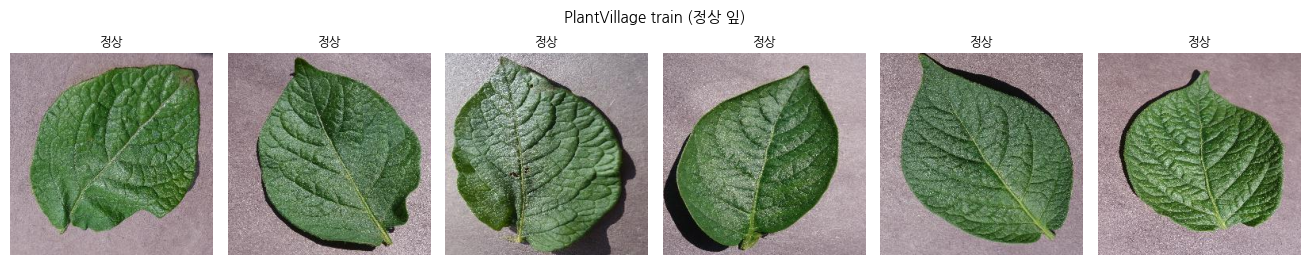

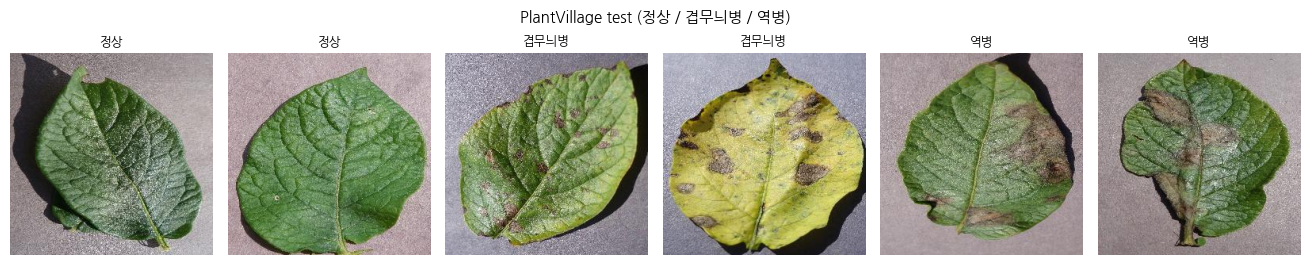

In [5]:
# ========== 샘플 이미지 시각화 ==========
def hf_row_to_pil(row) -> Image.Image:
    """HuggingFace row → RGB PIL Image."""
    img = row['image']
    if isinstance(img, Image.Image):
        return img.convert('RGB')
    return Image.fromarray(np.asarray(img)).convert('RGB')


def show_pv_grid(rows, title: str, ncols: int = 6):
    n = min(len(rows), ncols)
    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.7))
    if n == 1:
        axes = [axes]
    for ax, row in zip(axes, rows[:n]):
        ax.imshow(hf_row_to_pil(row))
        cls = row.get('class_name', '')
        ax.set_title(CLASS_DISPLAY.get(cls, cls), fontsize=9)
        ax.axis('off')
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


show_pv_grid([train_ds[i] for i in range(min(6, len(train_ds)))], 'PlantVillage train (정상 잎)')

by_class = {cls: [] for cls in SELECTED_CLASSES}
for i in range(len(test_ds)):
    cls = test_ds[i]['class_name']
    if len(by_class[cls]) < 2:
        by_class[cls].append(test_ds[i])
show_pv_grid(
    [row for cls in SELECTED_CLASSES for row in by_class[cls]],
    'PlantVillage test (정상 / 겹무늬병 / 역병)',
)


### 3. HuggingFace ViT 모델 로드

`google/vit-base-patch16-224` — 입력 224×224, 출력 `last_hidden_state` shape `[batch, 197, 768]`  
(197 = 1 CLS + 196 패치)


In [6]:
# ========== ViT 모델 및 전처리기 ==========
MODEL_NAME = 'google/vit-base-patch16-224'
BATCH_SIZE = 16

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

HIDDEN_DIM = model.config.hidden_size
print(f'모델: {MODEL_NAME}')
print(f'Hidden dim: {HIDDEN_DIM}')


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


모델: google/vit-base-patch16-224
Hidden dim: 768


### 4. Image Embedding: Pooling 구현

| Pooling | 설명 |
|---------|------|
| **CLS** | `[CLS]` 토큰(인덱스 0) — ViT 분류 헤드와 동일 |
| **Mean** | 패치 토큰(1~) 평균 — 공간 정보를 평균 반영 |

Cosine Similarity 사용 시 **L2 정규화**를 적용합니다.


In [7]:
# ========== Pooling 및 배치 인코딩 ==========
PoolingStrategy = Literal['cls', 'mean']


def pool_hidden_state(
    hidden_state: torch.Tensor,
    strategy: PoolingStrategy = 'cls',
) -> torch.Tensor:
    """[batch, seq_len, hidden_dim] → [batch, hidden_dim]"""
    if strategy == 'cls':
        return hidden_state[:, 0, :]
    if strategy == 'mean':
        return hidden_state[:, 1:, :].mean(dim=1)
    raise ValueError(f'지원하지 않는 pooling: {strategy}')


@torch.no_grad()
def encode_pil_batch(
    images: list[Image.Image],
    strategy: PoolingStrategy = 'cls',
    normalize: bool = True,
) -> torch.Tensor:
    inputs = processor(images=images, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    outputs = model(**inputs)
    emb = pool_hidden_state(outputs.last_hidden_state, strategy=strategy)
    if normalize:
        emb = F.normalize(emb, p=2, dim=-1)
    return emb.cpu()


def encode_hf_split(
    split,
    strategy: PoolingStrategy = 'cls',
    batch_size: int = BATCH_SIZE,
    max_samples: int | None = None,
) -> tuple[torch.Tensor, np.ndarray]:
    """HuggingFace split 전체 → (embeddings [N,D], labels [N])."""
    n = len(split) if max_samples is None else min(len(split), max_samples)
    all_emb: list[torch.Tensor] = []
    labels: list[int] = []

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        batch_imgs = [hf_row_to_pil(split[i]) for i in range(start, end)]
        all_emb.append(encode_pil_batch(batch_imgs, strategy=strategy))
        if 'label' in split.features:
            labels.extend(int(split[i]['label']) for i in range(start, end))
        else:
            labels.extend([0] * (end - start))

    return torch.cat(all_emb, dim=0), np.array(labels, dtype=np.int64)


### 5. Train / Test 임베딩 생성


In [8]:
# ========== 전체 split 임베딩 (CLS pooling) ==========
POOLING: PoolingStrategy = 'cls'

print('train (healthy) 임베딩 추출 중...')
emb_train, y_train = encode_hf_split(train_ds, strategy=POOLING)
print('train (3클래스) 임베딩 추출 중...')
emb_train_all, y_train_all = encode_hf_split(train_all, strategy=POOLING)
print('test 임베딩 추출 중...')
emb_test, y_test = encode_hf_split(test_ds, strategy=POOLING)

class_to_id = {c: i for i, c in enumerate(SELECTED_CLASSES)}
y_train_multi = np.array([class_to_id[n] for n in train_all['class_name']], dtype=np.int64)
y_test_multi = np.array([class_to_id[n] for n in test_ds['class_name']], dtype=np.int64)

print(f'emb_train:     {tuple(emb_train.shape)}')
print(f'emb_train_all: {tuple(emb_train_all.shape)}')
print(f'emb_test:      {tuple(emb_test.shape)}')


train (healthy) 임베딩 추출 중...
train (3클래스) 임베딩 추출 중...
test 임베딩 추출 중...
emb_train:     (80, 768)
emb_train_all: (160, 768)
emb_test:      (72, 768)


In [9]:
emb_train


tensor([[ 0.0154, -0.0447,  0.0499,  ...,  0.0048,  0.0024,  0.0358],
        [ 0.0378, -0.0336,  0.0451,  ..., -0.0066,  0.0060,  0.0471],
        [ 0.0392, -0.0140,  0.0837,  ..., -0.0211, -0.0252,  0.0278],
        ...,
        [ 0.0231, -0.0266,  0.0248,  ...,  0.0213, -0.0187,  0.0198],
        [ 0.0275, -0.0376,  0.0317,  ...,  0.0030,  0.0003,  0.0146],
        [ 0.0028, -0.0193,  0.0839,  ..., -0.0076, -0.0081,  0.0103]])

### 6. Cosine Similarity 분석

L2 정규화된 벡터 $a, b$ 에 대해:

$$\text{cosine\_sim}(a, b) = a \cdot b \quad (\|a\|=\|b\|=1)$$

정상 train의 **프로토타입(평균 임베딩)** 과 test 이미지 간 유사도를 계산하면,
병해 이미지는 일반적으로 유사도가 **낮게** 나타납니다.


In [10]:
# ========== Cosine Similarity 유틸 ==========
def cosine_similarity_matrix(embeddings: torch.Tensor) -> torch.Tensor:
    """[N, D] L2 정규화 임베딩 → [N, N] 유사도 행렬."""
    return embeddings @ embeddings.T


def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> float:
    return float(F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item())


# 정상 프로토타입: train 임베딩 평균 후 L2 정규화
normal_prototype = F.normalize(emb_train.mean(dim=0, keepdim=True), p=2, dim=-1)[0]
sim_to_normal = (emb_test @ normal_prototype).numpy()

print(f'정상 프로토타입 ↔ test Cosine Sim — mean: {sim_to_normal.mean():.4f}')
for lbl in [0, 1]:
    mask = y_test == lbl
    print(f'  {LABEL_NAMES[lbl]:8s}: {sim_to_normal[mask].mean():.4f}')

print('  세부 클래스:')
for cls in SELECTED_CLASSES:
    mask = np.array(test_ds['class_name']) == cls
    print(f'    {CLASS_DISPLAY[cls]:6s}: {sim_to_normal[mask].mean():.4f}')


정상 프로토타입 ↔ test Cosine Sim — mean: 0.6389
  healthy : 0.8689
  diseased: 0.5239
  세부 클래스:
    정상    : 0.8689
    겹무늬병  : 0.5027
    역병    : 0.5452


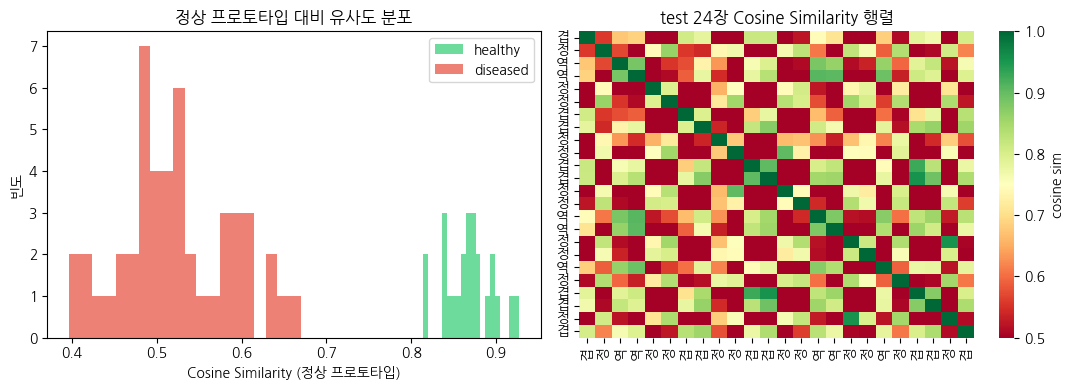

In [11]:
# ========== 유사도 분포 및 소규모 행렬 히트맵 ==========
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(sim_to_normal[y_test == 0], bins=20, alpha=0.7, label='healthy', color='#2ecc71')
axes[0].hist(sim_to_normal[y_test == 1], bins=20, alpha=0.7, label='diseased', color='#e74c3c')
axes[0].set_xlabel('Cosine Similarity (정상 프로토타입)')
axes[0].set_ylabel('빈도')
axes[0].set_title('정상 프로토타입 대비 유사도 분포')
axes[0].legend()

n_show = min(24, len(test_ds))
idx = RNG.choice(len(test_ds), size=n_show, replace=False)
sub_emb = emb_test[idx]
sub_names = [test_ds[int(i)]['class_name'] for i in idx]
sim_sub = cosine_similarity_matrix(sub_emb).numpy()

tick = [CLASS_DISPLAY[n][0] for n in sub_names]
sns.heatmap(sim_sub, ax=axes[1], cmap='RdYlGn', vmin=0.5, vmax=1.0,
            xticklabels=tick, yticklabels=tick, cbar_kws={'label': 'cosine sim'})
axes[1].set_title(f'test {n_show}장 Cosine Similarity 행렬')
plt.tight_layout()
plt.show()


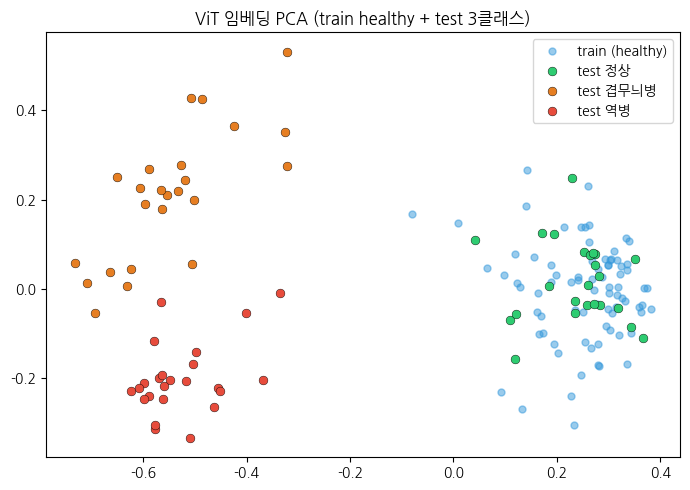

In [12]:
# ========== 임베딩 2D 시각화 (PCA) ==========
combined = torch.cat([emb_train, emb_test], dim=0).numpy()
coords = PCA(n_components=2, random_state=42).fit_transform(combined)
n_train = len(emb_train)
test_names = np.array(test_ds['class_name'])

colors = {
    'Potato___healthy': '#2ecc71',
    'Potato___Early_blight': '#e67e22',
    'Potato___Late_blight': '#e74c3c',
}

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coords[:n_train, 0], coords[:n_train, 1], c='#3498db', alpha=0.5,
           s=25, label='train (healthy)')
for cls in SELECTED_CLASSES:
    mask = test_names == cls
    ax.scatter(
        coords[n_train:][mask, 0], coords[n_train:][mask, 1],
        c=colors[cls], s=40, label=f'test {CLASS_DISPLAY[cls]}',
        edgecolors='k', linewidths=0.3,
    )
ax.set_title('ViT 임베딩 PCA (train healthy + test 3클래스)')
ax.legend()
plt.tight_layout()
plt.show()


### 7. PoC ① — 정상 프로토타입 기반 이상 탐지

PlantVillage를 MVTec AD와 같은 시나리오로 재구성합니다. **train에는 정상 잎만** 있다고 가정합니다.

1. train 임베딩 평균 → 정상 **프로토타입**  
2. test 이미지와의 Cosine Similarity = **정상 점수**  
3. train 점수의 하위 `PERCENTILE`% 를 임계값으로 사용 → 미만이면 **병해** 예측

> 실무에서는 검증용 정상 샘플 또는 운영 로그로 임계값을 재조정합니다.


In [13]:
# ========== PoC 1: 프로토타입 + 임계값 ==========
train_scores = (emb_train @ normal_prototype).numpy()
THRESHOLD_PERCENTILE = 5  # train 정상 점수 하위 5% 미만 → diseased

threshold = float(np.percentile(train_scores, THRESHOLD_PERCENTILE))
pred_proto = (sim_to_normal < threshold).astype(np.int64)

print(f'임계값 (cosine sim): {threshold:.4f}  (train p{THRESHOLD_PERCENTILE})')
print(f'Accuracy: {accuracy_score(y_test, pred_proto):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, -sim_to_normal):.4f}  (점수=−유사도)')
print(classification_report(y_test, pred_proto, target_names=['healthy', 'diseased']))


임계값 (cosine sim): 0.7632  (train p5)
Accuracy: 1.0000
ROC-AUC:  1.0000  (점수=−유사도)
              precision    recall  f1-score   support

     healthy       1.00      1.00      1.00        24
    diseased       1.00      1.00      1.00        48

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



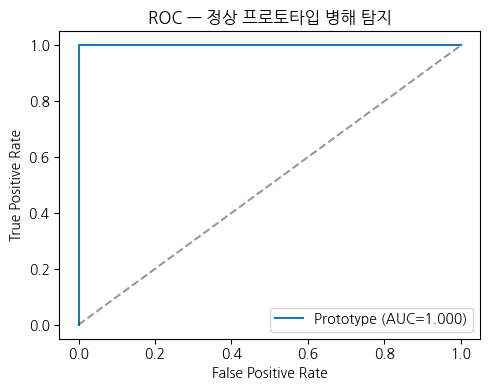

In [14]:
# ========== ROC 곡선 ==========
fpr, tpr, _ = roc_curve(y_test, -sim_to_normal)
auc = roc_auc_score(y_test, -sim_to_normal)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'Prototype (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC — 정상 프로토타입 병해 탐지')
plt.legend()
plt.tight_layout()
plt.show()


### 8. PoC ② — k-NN 메모리 기반 이상 탐지

train **정상 임베딩만** 메모리로 저장하고, test 이미지와 가장 가까운 k개 이웃의
평균 Cosine Similarity가 낮을수록 **병해**로 판정합니다. (라벨 누수 없음)

- Feature: ViT CLS 임베딩 (768-d)
- Memory: train 정상 잎
- k=5, 임계값은 train 이웃 점수 분포에서 산출


--- k-NN memory (cosine, k=5, train 정상만) ---
임계값 (kNN score): 0.8239
Accuracy: 0.9167
ROC-AUC:  1.0000
              precision    recall  f1-score   support

     healthy       1.00      0.75      0.86        24
    diseased       0.89      1.00      0.94        48

    accuracy                           0.92        72
   macro avg       0.94      0.88      0.90        72
weighted avg       0.93      0.92      0.91        72



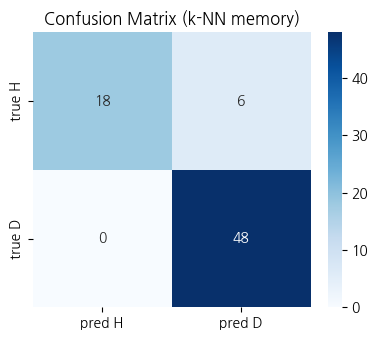

In [15]:
# ========== PoC 2: k-NN (train 정상 메모리만 사용) ==========
K_NEIGHBORS = 5

knn_mem = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, metric='cosine')
knn_mem.fit(emb_train.numpy(), np.zeros(len(emb_train), dtype=np.int64))

distances, _ = knn_mem.kneighbors(emb_test.numpy())
knn_scores = 1.0 - distances.mean(axis=1)

knn_train_scores = 1.0 - knn_mem.kneighbors(emb_train.numpy())[0].mean(axis=1)
knn_threshold = float(np.percentile(knn_train_scores, THRESHOLD_PERCENTILE))
pred_knn = (knn_scores < knn_threshold).astype(np.int64)

print('--- k-NN memory (cosine, k=5, train 정상만) ---')
print(f'임계값 (kNN score): {knn_threshold:.4f}')
print(f'Accuracy: {accuracy_score(y_test, pred_knn):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, -knn_scores):.4f}')
print(classification_report(y_test, pred_knn, target_names=['healthy', 'diseased']))

cm = confusion_matrix(y_test, pred_knn)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['pred H', 'pred D'],
            yticklabels=['true H', 'true D'])
ax.set_title('Confusion Matrix (k-NN memory)')
plt.tight_layout()
plt.show()


### 9. PoC ③ — 3클래스 k-NN 병해 분류

이상 탐지와 달리, 정상/겹무늬병/역병 **라벨을 사용**해 질병 종류까지 구분합니다.
ViT 임베딩 위에서 k-NN만 학습하므로 백본 fine-tuning은 없습니다.


--- 3클래스 k-NN (cosine, k=5) ---
Accuracy: 1.0000
              precision    recall  f1-score   support

          정상       1.00      1.00      1.00        24
        겹무늬병       1.00      1.00      1.00        24
          역병       1.00      1.00      1.00        24

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



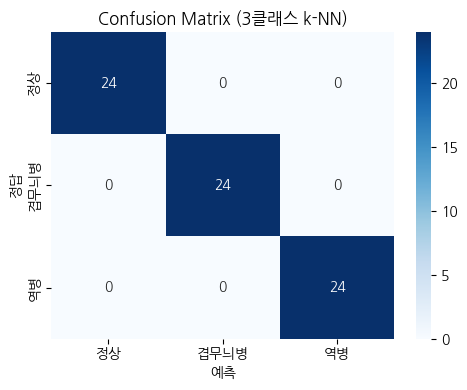

In [16]:
# ========== PoC 3: 지도 k-NN (healthy / early blight / late blight) ==========
knn_clf = KNeighborsClassifier(n_neighbors=K_NEIGHBORS, metric='cosine')
knn_clf.fit(emb_train_all.numpy(), y_train_multi)
pred_multi = knn_clf.predict(emb_test.numpy())

multi_names = [CLASS_DISPLAY[c] for c in SELECTED_CLASSES]
print('--- 3클래스 k-NN (cosine, k=5) ---')
print(f'Accuracy: {accuracy_score(y_test_multi, pred_multi):.4f}')
print(classification_report(y_test_multi, pred_multi, target_names=multi_names))

cm_multi = confusion_matrix(y_test_multi, pred_multi)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=multi_names, yticklabels=multi_names)
ax.set_xlabel('예측')
ax.set_ylabel('정답')
ax.set_title('Confusion Matrix (3클래스 k-NN)')
plt.tight_layout()
plt.show()


### 10. Pooling 방식 비교 (CLS vs Mean)


In [17]:
# ========== CLS vs Mean pooling AUC 비교 ==========
results = []
for strategy in ['cls', 'mean']:
    e_tr, _ = encode_hf_split(train_ds, strategy=strategy)
    e_te, y_te = encode_hf_split(test_ds, strategy=strategy)
    proto = F.normalize(e_tr.mean(dim=0, keepdim=True), p=2, dim=-1)[0]
    scores = (e_te @ proto).numpy()
    auc = roc_auc_score(y_te, -scores)
    results.append((strategy, auc))
    print(f'{strategy:5s} pooling — ROC-AUC (prototype): {auc:.4f}')

best = max(results, key=lambda x: x[1])[0]
print(f'\n권장 pooling (이 데이터 기준): {best}')


cls   pooling — ROC-AUC (prototype): 1.0000
mean  pooling — ROC-AUC (prototype): 1.0000

권장 pooling (이 데이터 기준): cls


### 11. (선택) Colab에서 단일 이미지 업로드 테스트


Saving 00b1f292-23dd-44d4-aad3-c1ffb6a6ad5a___RS_LB 4479.JPG to 00b1f292-23dd-44d4-aad3-c1ffb6a6ad5a___RS_LB 4479.JPG
00b1f292-23dd-44d4-aad3-c1ffb6a6ad5a___RS_LB 4479.JPG: cosine_sim=0.5712 → 이진: diseased / 3클래스: 역병


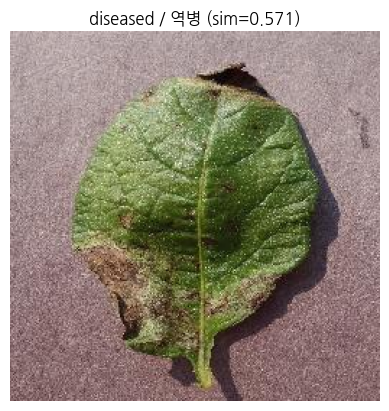

In [18]:
# ========== Colab 업로드 → 정상 유사도 점수 ==========
if IN_COLAB:
    from google.colab import files

    uploaded = files.upload()
    for name, data in uploaded.items():
        img = Image.open(io.BytesIO(data)).convert('RGB')
        emb = encode_pil_batch([img], strategy=POOLING)[0]
        score = float(emb @ normal_prototype)
        verdict = 'diseased' if score < threshold else 'healthy'
        disease_id = int(knn_clf.predict(emb.unsqueeze(0).numpy())[0])
        disease_name = CLASS_DISPLAY[SELECTED_CLASSES[disease_id]]
        print(f'{name}: cosine_sim={score:.4f} → 이진: {verdict} / 3클래스: {disease_name}')
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'{verdict} / {disease_name} (sim={score:.3f})')
        plt.show()
else:
    print('Colab에서만 업로드 셀이 동작합니다. 로컬에서는 PIL 경로로 encode_pil_batch를 호출하세요.')


### 12. 정리

| 단계 | 내용 |
|------|------|
| 데이터 | PlantVillage Potato 3클래스 — 클래스당 소수 장만 다운로드 |
| 표현 | ViT-Base CLS/Mean pooling → 768-d 임베딩 |
| 유사도 | 정상 프로토타입 Cosine Similarity, 행렬·분포 시각화 |
| PoC 1 | 비지도 이상 탐지 (train 정상만, percentile 임계값) |
| PoC 2 | k-NN 메모리 이상 탐지 (train 정상만, 라벨 누수 없음) |
| PoC 3 | 3클래스 k-NN (정상 / 겹무늬병 / 역병) |

**다음 단계 (실무 확장)**
- 다른 작물(토마토, 사과 등)로 `SELECTED_CLASSES`만 바꿔 재실험
- 클래스당 샘플 수를 늘리거나 Linear Probe / Fine-tuning
- Grad-CAM으로 병반 위치 시각화 (`07_Heatmap_Grad_CAM.ipynb`)

**참고**
- [PlantVillage Dataset (GitHub)](https://github.com/spMohanty/PlantVillage-Dataset)
- [Mohanty et al., Frontiers in Plant Science 2016](https://doi.org/10.3389/fpls.2016.01419)
